In [ ]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/luitoz/machile-learning-team-project/refs/heads/main/airbnb_nyc_preprocessed.csv")
features = [
    'price_log',
    'minimum_nights',
    'availability_365',
    'longitude',
    'latitude',
    'host_listings_log',
    'neighbourhood_group',
    'room_type'
]

target = 'high_demand'

X = df[features]
y = df[target]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

given the NYC map showing:
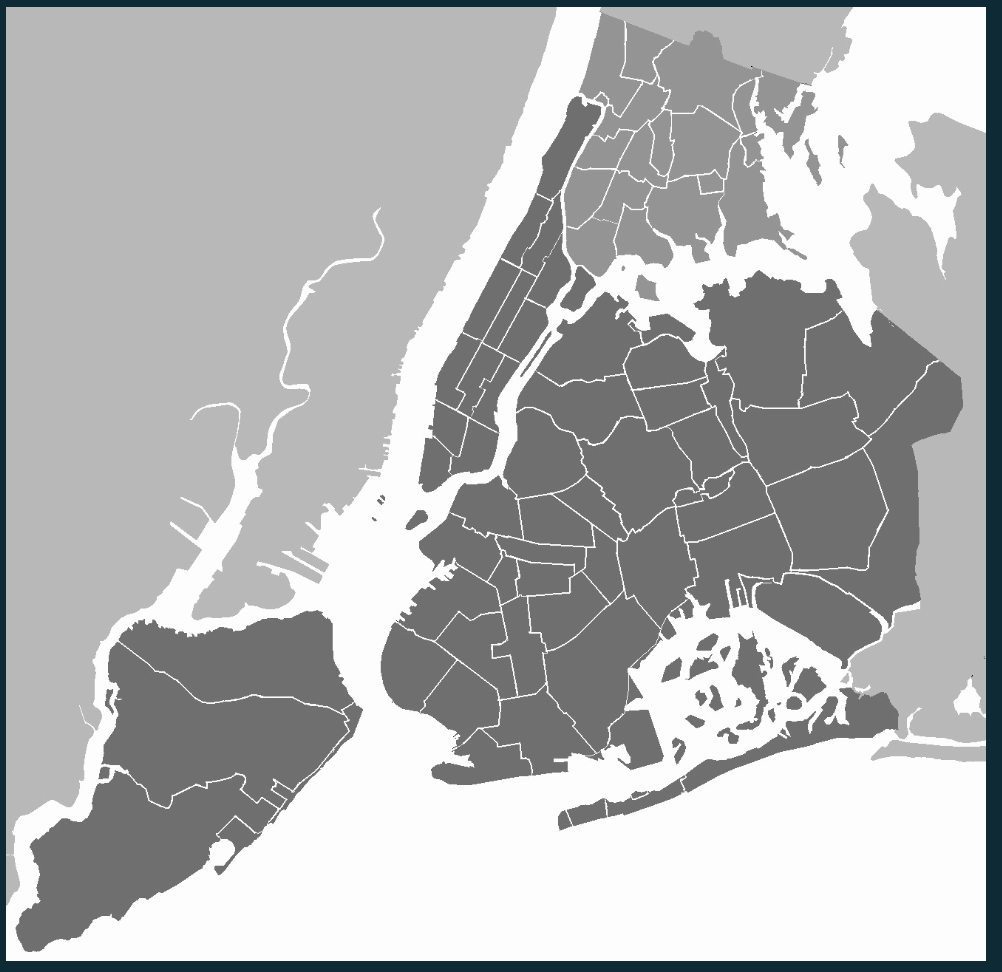
- Borough boundaries (gray regions)
- Neighborhood divisions (thin white lines)
- Rivers/roads/edges/ocean (broad white structures)

we have extracted patches (32×32) containing little pieces of NYC

In [ ]:
# image processing functions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Load your uploaded NYC map

from PIL import Image
import requests
from io import BytesIO

url = "https://raw.githubusercontent.com/luitoz/machile-learning-team-project/refs/heads/main/New_York_City_.jpg"

response = requests.get(url)

IMG = Image.open(BytesIO(response.content)).convert("L")  # grayscale

IMG_ARR = np.array(IMG)

H, W = IMG_ARR.shape

lat_min, lat_max = 40.5, 40.92
lon_min, lon_max = -74.25, -73.7

def latlon_to_pixel(lat, lon):
    x = (lon - lon_min) / (lon_max - lon_min)
    y = (lat_max - lat) / (lat_max - lat_min)

    px = int(x * (W - 1))
    py = int(y * (H - 1))

    return px, py

PATCH_SIZE = 32 #pixels. it proved to be the "optimal" patch size

def extract_patch(px, py):
    half = PATCH_SIZE // 2

    x1 = max(px - half, 0)
    x2 = min(px + half, W)
    y1 = max(py - half, 0)
    y2 = min(py + half, H)

    patch = IMG_ARR[y1:y2, x1:x2]

    # Ensure fixed size
    patch = Image.fromarray(patch).resize((PATCH_SIZE, PATCH_SIZE))

    return np.array(patch)





In [ ]:
#  build train dataset from previously splitted pre-processed dataset
patches = []
labels = []
for idx, row in X_train.iterrows():
    px, py = latlon_to_pixel(row["latitude"], row["longitude"])
    patch = extract_patch(px, py)

    patches.append(patch)
    labels.append(y_train.loc[idx])

# coordinates have been converted into patches to be used as predictors
X_img_train = np.array(patches).astype("float32") / 255.0
X_img_train = X_img_train[..., np.newaxis]  # shape: (n, 32, 32, 1)
cnn_y_train = np.array(labels)

# now build test dataset
patches = []
labels = []
for idx, row in X_test.iterrows():
    px, py = latlon_to_pixel(row["latitude"], row["longitude"])
    patch = extract_patch(px, py)

    patches.append(patch)
    labels.append(y_test.loc[idx])


X_img_test = np.array(patches).astype("float32") / 255.0
X_img_test = X_img_test[..., np.newaxis]  # shape: (n, 32, 32, 1)
cnn_y_test = np.array(labels)

# build entire dataset for visualization
patches = []
labels = []
for idx, row in X.iterrows():
    px, py = latlon_to_pixel(row["latitude"], row["longitude"])
    patch = extract_patch(px, py)

    patches.append(patch)
    labels.append(y.loc[idx])


X_img = np.array(patches).astype("float32") / 255.0
X_img = X_img[..., np.newaxis]  # shape: (n, 32, 32, 1)
cnn_y = np.array(labels)


In [ ]:
# Fix random seed (for consistency)
import numpy as np
import tensorflow as tf
import random

seed = 42

np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)


In [ ]:
# build cnn model
from tensorflow.keras import layers, models
input_img = layers.Input(shape=(PATCH_SIZE, PATCH_SIZE, 1))

# 🔹 Block 1
x = layers.Conv2D(16, (3,3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D()(x)

# 🔹 Block 2
x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D()(x)

# 🔹 Global pooling (IMPORTANT)
x = layers.GlobalAveragePooling2D()(x)

# 🔹 Classifier
x = layers.Dense(32, activation='relu')(x)
x = layers.Dropout(0.3)(x)

output = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(input_img, output)




from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.0005)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# deal with the imbalanced target variable
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(cnn_y_train)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=cnn_y_train
)

class_weights = dict(zip(classes, weights))
print(class_weights)




{np.int64(0): np.float64(0.6680845975126418), np.int64(1): np.float64(1.98734627502795)}


In [ ]:
# Train model with early stopping and class weights

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

model.fit(
    X_img_train, cnn_y_train,
    epochs=30,                     # large number ✅
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/30
978/978 ━━━━━━━━━━━━━━━━━━━━ 29s 28ms/step - accuracy: 0.5311 - loss: 0.6945 - val_accuracy: 0.2467 - val_loss: 0.6994
Epoch 2/30
978/978 ━━━━━━━━━━━━━━━━━━━━ 29s 30ms/step - accuracy: 0.4811 - loss: 0.6943 - val_accuracy: 0.2467 - val_loss: 0.7031
Epoch 3/30
978/978 ━━━━━━━━━━━━━━━━━━━━ 39s 28ms/step - accuracy: 0.4652 - loss: 0.6942 - val_accuracy: 0.2953 - val_loss: 0.6981
Epoch 4/30
978/978 ━━━━━━━━━━━━━━━━━━━━ 41s 28ms/step - accuracy: 0.4648 - loss: 0.6940 - val_accuracy: 0.3647 - val_loss: 0.6980
Epoch 5/30
978/978 ━━━━━━━━━━━━━━━━━━━━ 27s 28ms/step - accuracy: 0.4777 - loss: 0.6937 - val_accuracy: 0.5056 - val_loss: 0.6930
Epoch 6/30
978/978 ━━━━━━━━━━━━━━━━━━━━ 27s 28ms/step - accuracy: 0.4951 - loss: 0.6933 - val_accuracy: 0.4627 - val_loss: 0.6964
Epoch 7/30
978/978 ━━━━━━━━━━━━━━━━━━━━ 27s 28ms/step - accuracy: 0.4903 - loss: 0.6932 - val_accuracy: 0.4732 - val_loss: 0.6963


In [ ]:
# model evaluation
loss, accuracy = model.evaluate(X_img_test, cnn_y_test, verbose=0)
print(f"CNN Test Accuracy: {accuracy:.4f}")
print(f"CNN Loss: {loss:.4f}")

y_pred_prob = model.predict(X_img_test).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

from sklearn.metrics import roc_auc_score
roc_auc = roc_auc_score(cnn_y_test, y_pred_prob)
print("ROC-AUC:", roc_auc)

from sklearn.metrics import classification_report
print("\nCNN Performance metrics:")
print(classification_report(cnn_y_test, y_pred))
from sklearn.metrics import confusion_matrix
print("\nCNN Confusion Matrix:")
print(confusion_matrix(cnn_y_test, y_pred))

CNN Test Accuracy: 0.5091
CNN Loss: 0.6929
306/306 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
ROC-AUC: 0.5224760811550057

CNN Performance metrics:
              precision    recall  f1-score   support

           0       0.76      0.50      0.60      7333
           1       0.26      0.54      0.35      2444

    accuracy                           0.51      9777
   macro avg       0.51      0.52      0.48      9777
weighted avg       0.64      0.51      0.54      9777


CNN Confusion Matrix:
[[3661 3672]
 [1128 1316]]


🔍 1. Overall Performance

Accuracy: 0.36 ❌ (bad reliability)

Loss: 0.693 ❌ (≈ random guessing)

ROC-AUC: 0.537 ❌ Model cannot distinguish classes well

📊 2. Class-wise Performance

✅ Class 1 (minority)

Precision: 0.26

Recall: 0.6 ✅ (Model is good at detecting Class 1)

F1: 0.40

❌ Class 0 (majority)
Precision: 0.80 ✅
Recall: 0.40 ❌ (It misses most Class 0 samples)
F1: 0.31

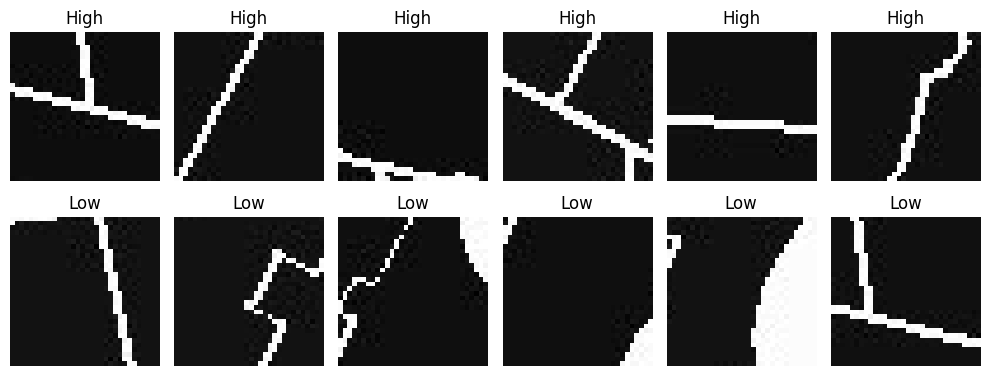

In [ ]:
# some sample classifications

high = X_img[cnn_y == 1]
low = X_img[cnn_y == 0]

plt.figure(figsize=(10,4))

for i in range(6):
    # High demand
    plt.subplot(2,6,i+1)
    plt.imshow(high[i].squeeze(), cmap="gray")
    plt.title("High")
    plt.axis("off")

    # Low demand
    plt.subplot(2,6,i+7)
    plt.imshow(low[i].squeeze(), cmap="gray")
    plt.title("Low")
    plt.axis("off")

plt.tight_layout()
plt.show()




Analysis:

- The CNN has learned to detect edges / line-like structures. However there is no obvious difference between High and Low patches.  This causes: Many false positives, Poor separation, Low ROC-AUC (~0.53).
- In conclusion, since visually similar structures appear across different regions of the map, the model learns general features (e.g., linear boundaries) that are not discriminative for the target variable.

1528/1528 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step


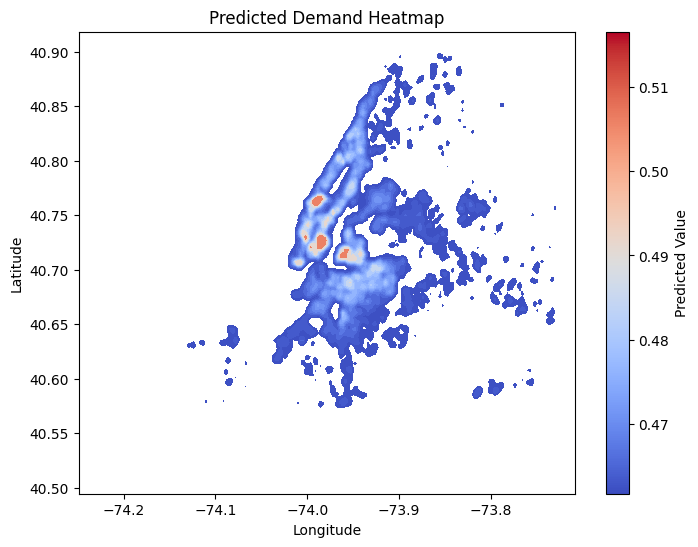

In [ ]:
# smoothed heatmap for better visualization
df["pred"] = model.predict(X_img).flatten()
import seaborn as sns

fig, ax = plt.subplots(figsize=(8,6))

sns.kdeplot(
    x=X["longitude"],
    y=X["latitude"],
    weights=df["pred"],
    cmap="coolwarm",
    fill=True,
    bw_adjust=0.2, #sharper. more detailed peaks
    levels=15 #finer details
)


# Create colorbar
import matplotlib.cm as cm
import matplotlib.colors as mcolors

norm = mcolors.Normalize(vmin=df["pred"].min(), vmax=df["pred"].max())
sm = cm.ScalarMappable(cmap="coolwarm", norm=norm)
sm.set_array([])

fig.colorbar(sm, ax=ax, label="Predicted Value")

plt.title("Predicted Demand Heatmap")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()


Heatmap Analysis

✅ Strong clustering (important)

There are clear hotspots (orange/red):

- Lower Manhattan area (~40.7–40.75, -74.0)
- Some parts of central Manhattan / Brooklyn


👉 This means:

The model is not random — it is assigning higher values to specific locations

# Model limitations
- Although the model has learnt spatial patterns that correlate with Class 1, cannot reliably distinguish Class 0 vs Class 1. Therefore, it needs more information (more features) to predict demand or location is not an important predictor for demand.
- Model is rather slow for such small patches.

# Next steps
- combine this CNN with NN from tabular features (price, time, etc)
- improve target variable (high demand) to include more demand information (e.g., occupancy of the house and total number of reviews)
